# 이미지 개별 검색 테스트 (멀티모달 임베딩)

PDF에서 이미지를 개별 추출하고, **캡션 + 주변 텍스트를 함께 멀티모달 임베딩**하여 검색 품질을 높인 파이프라인.

- **임베딩 모델**: `gemini-embedding-2-preview`
- **검색 단위**: 개별 이미지 + 컨텍스트 텍스트 (멀티모달)
- **쿼리**: 텍스트 또는 이미지
- **개선점**: 이미지만 임베딩하면 컨텍스트가 없어 검색 품질이 낮았음 → 캡션/주변 텍스트를 함께 임베딩

In [19]:
%pip install google-genai faiss-cpu pymupdf Pillow numpy

/Users/goldenplanet/jinsup_space/embedding002_test/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
import os
import re
import time
import io
import numpy as np
import faiss
import fitz
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
from google import genai
from google.genai import types

client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))

EMBEDDING_MODEL = "gemini-embedding-2-preview"
EMBEDDING_DIM = 3072
PDF_PATH = "data/헤리티지 역사와 과학 제58권 제4호(통권 제110권).pdf"

print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Embedding dimension: {EMBEDDING_DIM}")

Embedding model: gemini-embedding-2-preview
Embedding dimension: 3072


## PDF에서 개별 이미지 + 컨텍스트 텍스트 추출

각 페이지에서 이미지를 추출하고, **캡션 + 주변 문단 텍스트**를 함께 가져옵니다.
- 캡션: 이미지 bbox 아래 50px 이내 텍스트에서 "그림/Figure/표/사진" 등 패턴 매칭
- 주변 텍스트: 이미지 bbox 위아래 100px 이내의 모든 텍스트 블록

In [43]:
# 캡션 패턴
CAPTION_PATTERN = re.compile(
    r'(그림|Figure|Fig\.|표|Table|사진|도면|Photo|Plate)\s*\d+[.\-]?\s*.{0,100}',
    re.IGNORECASE
)

def extract_images_with_context(pdf_path: str, min_size: int = 100) -> list[dict]:
    """PDF에서 개별 이미지 + 캡션 + 주변 텍스트를 함께 추출."""
    doc = fitz.open(pdf_path)
    images = []

    for page_num in range(len(doc)):
        page = doc[page_num]
        image_list = page.get_images(full=True)
        if not image_list:
            continue

        # 이미지 위치 정보 (bbox)
        image_infos = page.get_image_info(xrefs=True)
        # 텍스트 블록 (x0, y0, x1, y1, text, block_no, block_type)
        text_blocks = page.get_text("blocks")

        for img_idx, img_info in enumerate(image_list):
            xref = img_info[0]
            try:
                base_image = doc.extract_image(xref)
                if base_image is None:
                    continue

                width = base_image["width"]
                height = base_image["height"]
                if width < min_size or height < min_size:
                    continue

                # PNG 변환
                img = PILImage.open(io.BytesIO(base_image["image"]))
                buf = io.BytesIO()
                img.convert("RGB").save(buf, format="PNG")
                png_bytes = buf.getvalue()

                # 이미지 bbox 찾기
                img_bbox = None
                for info in image_infos:
                    if info.get("xref") == xref:
                        img_bbox = info["bbox"]  # (x0, y0, x1, y1)
                        break

                # 캡션 찾기: 이미지 아래 50px 이내
                caption = None
                nearby_texts = []
                if img_bbox:
                    img_top, img_bottom = img_bbox[1], img_bbox[3]
                    for block in text_blocks:
                        if block[6] != 0:  # 텍스트 블록만
                            continue
                        block_top, block_bottom = block[1], block[3]
                        block_text = block[4].strip()
                        if not block_text:
                            continue

                        # 캡션: 이미지 바로 아래 50px 이내
                        if caption is None and 0 <= block_top - img_bottom < 50:
                            match = CAPTION_PATTERN.search(block_text)
                            if match:
                                caption = match.group(0).strip()

                        # 주변 텍스트: 이미지 위아래 100px 이내
                        if (block_bottom > img_top - 100) and (block_top < img_bottom + 100):
                            nearby_texts.append(block_text)

                # 캡션 폴백: 페이지 텍스트에서 순서대로 매칭
                if caption is None:
                    page_text = page.get_text()
                    matches = list(CAPTION_PATTERN.finditer(page_text))
                    if img_idx < len(matches):
                        caption = matches[img_idx].group(0).strip()

                # 컨텍스트 텍스트 조합
                context_text = ""
                if caption:
                    context_text = caption
                if nearby_texts:
                    nearby_joined = " ".join(nearby_texts)
                    if context_text:
                        context_text += "\n" + nearby_joined
                    else:
                        context_text = nearby_joined

                images.append({
                    "page": page_num + 1,
                    "img_idx": img_idx,
                    "width": width,
                    "height": height,
                    "mime_type": "image/png",
                    "bytes": png_bytes,
                    "caption": caption,
                    "context_text": context_text,
                })
            except Exception as e:
                print(f"  페이지 {page_num+1} 이미지 #{img_idx} 추출 실패: {e}")
                continue

    doc.close()
    return images

t0 = time.time()
all_images = extract_images_with_context(PDF_PATH)
elapsed = time.time() - t0
print(f"총 {len(all_images)}개 이미지 추출 ({elapsed:.2f}초)")

# 컨텍스트 통계
with_caption = sum(1 for img in all_images if img["caption"])
with_context = sum(1 for img in all_images if img["context_text"])
print(f"캡션 있는 이미지: {with_caption}/{len(all_images)}")
print(f"컨텍스트 텍스트 있는 이미지: {with_context}/{len(all_images)}")

# 페이지별 이미지 수 요약
from collections import Counter
page_counts = Counter(img["page"] for img in all_images)
print(f"이미지가 있는 페이지: {len(page_counts)}개")
print(f"페이지당 평균: {len(all_images)/len(page_counts):.1f}개")

총 392개 이미지 추출 (7.39초)
캡션 있는 이미지: 318/392
컨텍스트 텍스트 있는 이미지: 388/392
이미지가 있는 페이지: 104개
페이지당 평균: 3.8개


페이지 1, 이미지 #0 (152x312)
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


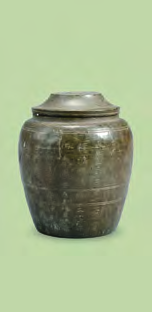

페이지 1, 이미지 #1 (148x312)
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


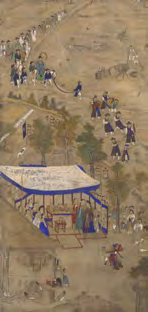

페이지 1, 이미지 #2 (153x312)
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


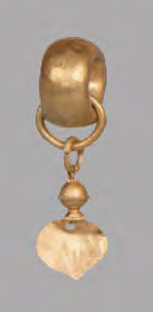

페이지 1, 이미지 #3 (152x312)
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


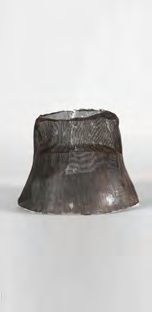

페이지 3, 이미지 #0 (152x312)
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


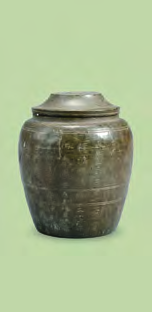

In [44]:
# 추출된 이미지 샘플 미리보기 (처음 5개, 캡션 포함)
for img in all_images[:5]:
    label = img["caption"] if img["caption"] else f"이미지 #{img['img_idx']}"
    print(f"페이지 {img['page']}, {label} ({img['width']}x{img['height']})")
    if img["context_text"]:
        preview = img["context_text"][:100] + "..." if len(img["context_text"]) > 100 else img["context_text"]
        print(f"  컨텍스트: {preview}")
    display(IPImage(data=img["bytes"], width=300))

## 멀티모달 임베딩 & FAISS 인덱스 구축

이미지 + 컨텍스트 텍스트를 하나의 `Content`로 묶어서 임베딩합니다.
- 컨텍스트 텍스트가 있는 이미지: `[이미지 Part, 텍스트 Part]` → 멀티모달 임베딩
- 컨텍스트 없는 이미지: `[이미지 Part]` → 이미지만 임베딩 (기존과 동일)

In [45]:
# 멀티모달 임베딩: 이미지 + 컨텍스트 텍스트를 함께 임베딩
def embed_images_multimodal(images: list[dict], batch_size: int = 5) -> np.ndarray:
    """이미지 + 컨텍스트 텍스트를 멀티모달 Content로 묶어 임베딩"""
    all_embeddings = []
    total = len(images)

    for i in range(0, total, batch_size):
        batch = images[i : i + batch_size]
        contents = []
        for img in batch:
            parts = [types.Part.from_bytes(data=img["bytes"], mime_type=img["mime_type"])]
            # 컨텍스트 텍스트가 있으면 함께 임베딩
            if img["context_text"]:
                parts.append(types.Part.from_text(text=img["context_text"]))
            contents.append(types.Content(parts=parts))

        response = client.models.embed_content(
            model=EMBEDDING_MODEL,
            contents=contents,
            config=types.EmbedContentConfig(
                output_dimensionality=EMBEDDING_DIM,
                task_type="RETRIEVAL_DOCUMENT",
            ),
        )
        for emb in response.embeddings:
            all_embeddings.append(emb.values)
        print(f"  임베딩 완료: {min(i + batch_size, total)}/{total} 이미지")

    return np.array(all_embeddings, dtype=np.float32)

t0 = time.time()
embeddings = embed_images_multimodal(all_images)
embed_time = time.time() - t0
print(f"\n전체 임베딩 완료: {embeddings.shape} ({embed_time:.2f}초)")

# FAISS 인덱스 구축
faiss.normalize_L2(embeddings)
index = faiss.IndexFlatIP(EMBEDDING_DIM)
index.add(embeddings)
print(f"FAISS 인덱스 구축 완료: {index.ntotal}개 벡터")

  임베딩 완료: 5/392 이미지
  임베딩 완료: 10/392 이미지
  임베딩 완료: 15/392 이미지
  임베딩 완료: 20/392 이미지
  임베딩 완료: 25/392 이미지
  임베딩 완료: 30/392 이미지
  임베딩 완료: 35/392 이미지
  임베딩 완료: 40/392 이미지
  임베딩 완료: 45/392 이미지
  임베딩 완료: 50/392 이미지
  임베딩 완료: 55/392 이미지
  임베딩 완료: 60/392 이미지
  임베딩 완료: 65/392 이미지
  임베딩 완료: 70/392 이미지
  임베딩 완료: 75/392 이미지
  임베딩 완료: 80/392 이미지
  임베딩 완료: 85/392 이미지
  임베딩 완료: 90/392 이미지
  임베딩 완료: 95/392 이미지
  임베딩 완료: 100/392 이미지
  임베딩 완료: 105/392 이미지
  임베딩 완료: 110/392 이미지
  임베딩 완료: 115/392 이미지
  임베딩 완료: 120/392 이미지
  임베딩 완료: 125/392 이미지
  임베딩 완료: 130/392 이미지
  임베딩 완료: 135/392 이미지
  임베딩 완료: 140/392 이미지
  임베딩 완료: 145/392 이미지
  임베딩 완료: 150/392 이미지
  임베딩 완료: 155/392 이미지
  임베딩 완료: 160/392 이미지
  임베딩 완료: 165/392 이미지
  임베딩 완료: 170/392 이미지
  임베딩 완료: 175/392 이미지
  임베딩 완료: 180/392 이미지
  임베딩 완료: 185/392 이미지
  임베딩 완료: 190/392 이미지
  임베딩 완료: 195/392 이미지
  임베딩 완료: 200/392 이미지
  임베딩 완료: 205/392 이미지
  임베딩 완료: 210/392 이미지
  임베딩 완료: 215/392 이미지
  임베딩 완료: 220/392 이미지
  임베딩 완료: 225/392 이미지
  임베딩 완료: 230/392 이미지
  임베딩 완료

## 검색

텍스트 쿼리 또는 이미지 쿼리로 유사 이미지를 검색합니다.

In [46]:
# 검색 함수 (텍스트 쿼리 / 이미지 쿼리 모두 지원)
def search_by_text(query: str, top_k: int = 5) -> list[dict]:
    """텍스트로 유사 이미지 검색"""
    t0 = time.time()
    response = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=query,
        config=types.EmbedContentConfig(
            output_dimensionality=EMBEDDING_DIM,
            task_type="RETRIEVAL_QUERY",
        ),
    )
    query_emb = np.array([response.embeddings[0].values], dtype=np.float32)
    faiss.normalize_L2(query_emb)
    scores, indices = index.search(query_emb, top_k)
    search_time = time.time() - t0

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
        img = all_images[idx]
        results.append({
            "rank": rank + 1,
            "score": float(score),
            "page": img["page"],
            "img_idx": img["img_idx"],
            "width": img["width"],
            "height": img["height"],
            "bytes": img["bytes"],
            "caption": img["caption"],
            "context_text": img["context_text"],
        })

    print(f"텍스트 검색 완료 ({search_time:.3f}초) - top {top_k}")
    return results

def search_by_image(image_bytes: bytes, mime_type: str = "image/png", top_k: int = 5) -> list[dict]:
    """이미지로 유사 이미지 검색"""
    t0 = time.time()
    response = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=types.Content(
            parts=[types.Part.from_bytes(data=image_bytes, mime_type=mime_type)]
        ),
        config=types.EmbedContentConfig(
            output_dimensionality=EMBEDDING_DIM,
            task_type="RETRIEVAL_QUERY",
        ),
    )
    query_emb = np.array([response.embeddings[0].values], dtype=np.float32)
    faiss.normalize_L2(query_emb)
    scores, indices = index.search(query_emb, top_k)
    search_time = time.time() - t0

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
        img = all_images[idx]
        results.append({
            "rank": rank + 1,
            "score": float(score),
            "page": img["page"],
            "img_idx": img["img_idx"],
            "width": img["width"],
            "height": img["height"],
            "bytes": img["bytes"],
            "caption": img["caption"],
            "context_text": img["context_text"],
        })

    print(f"이미지 검색 완료 ({search_time:.3f}초) - top {top_k}")
    return results

def display_results(results: list[dict]):
    """검색 결과 이미지 + 캡션 표시"""
    for r in results:
        label = r["caption"] if r["caption"] else f"이미지 #{r['img_idx']}"
        print(f"\n#{r['rank']} | 페이지 {r['page']}, {label} | "
              f"{r['width']}x{r['height']} | 유사도: {r['score']:.4f}")
        if r["context_text"]:
            preview = r["context_text"][:150] + "..." if len(r["context_text"]) > 150 else r["context_text"]
            print(f"  컨텍스트: {preview}")
        display(IPImage(data=r["bytes"], width=400))

## 테스트 1: 텍스트로 이미지 검색


쿼리: 두 자락치마
텍스트 검색 완료 (0.585초) - top 3

#1 | 페이지 185, 그림 6  『풍공유보도략』 및 묘법원의 두 자락 치마55 A: 『풍공유보도략』의 치마 B: 묘법원 소장 치마. | 608x279 | 유사도: 0.4875
  컨텍스트: 그림 6  『풍공유보도략』 및 묘법원의 두 자락 치마55 A: 『풍공유보도략』의 치마 B: 묘법원 소장 치마.
두 자락 치마의 출처는 선행연구에서 고찰한 바 있다(그림 6). 선행연구에서는 문헌, 유물, 회화를 종 합적으로 분석하여, 이를 명 신종이 히데요시에게 보 낸...


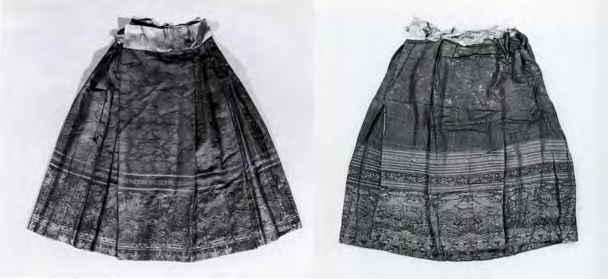


#2 | 페이지 185, 그림 6  『풍공유보도략』 및 묘법원의 두 자락 치마55 A: 『풍공유보도략』의 치마 B: 묘법원 소장 치마. | 212x274 | 유사도: 0.4751
  컨텍스트: 그림 6  『풍공유보도략』 및 묘법원의 두 자락 치마55 A: 『풍공유보도략』의 치마 B: 묘법원 소장 치마.
있다(그림 6). 선행연구에서는 문헌, 유물, 회화를 종 합적으로 분석하여, 이를 명 신종이 히데요시에게 보 낸 하사품의 일부일 가능성을 제기한 바 있다.54...


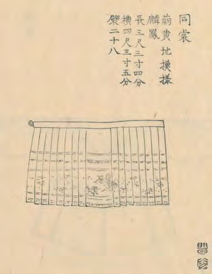


#3 | 페이지 183, 이미지 #10 | 308x177 | 유사도: 0.4709
  컨텍스트: 및 묘법원 소장 복식 중 피변복 일습에 해당하는 것을 <그림 5>와 같이 정리하였다. 피변복의 상(裳)은 전상 (前裳)과 후상(後裳)이 서로 연결된 형태인데, 도설과 치마와 운견·통수·스란 원령 『풍공유보도략』 도설 및 묘법원 소장 유품에는 칙 유에 기록된 상복과 피변...


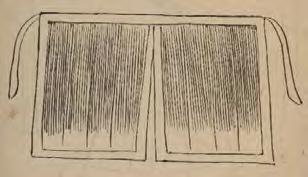


쿼리: 찢어진 옷
텍스트 검색 완료 (0.503초) - top 3

#1 | 페이지 87, 그림 33)는 원단을 길게 자른 후 한쪽 끝을 | 323x360 | 유사도: 0.4192
  컨텍스트: 그림 33)는 원단을 길게 자른 후 한쪽 끝을
19세기 말 《채용신 평생도》 <도문도> 속 등장인물 복식 연구     85 笠), 동다리, 전복, 전대(纏帶) 차림의 군복에 행전을 차고 혜를 신은 모습으로, 관가의 공역(公役)으로 급제 자를 위한 행사에 동원된 것으로 ...


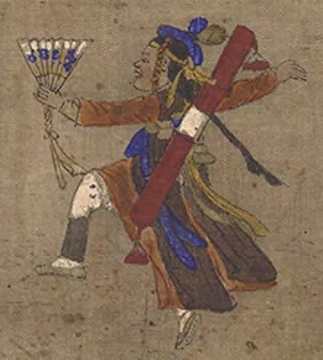


#2 | 페이지 184, 이미지 #1 | 329x180 | 유사도: 0.4145
  컨텍스트: 도설 없음


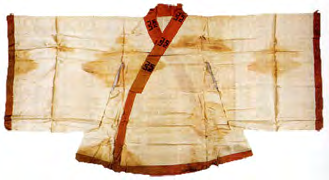


#3 | 페이지 87, 그림 30  전립(동아대학교 2019: 36). | 326x201 | 유사도: 0.4134
  컨텍스트: 그림 30  전립(동아대학교 2019: 36).
복은 대부분 검은색 겉감에 붉은색 안감으로 만든 겹 옷이다. <그림 31, 32>은 고려대학교 박물관 소장, 김 병기(金炳冀, 1818~1875) 일가의 복식 중 19C 동다리 와 전복으로, 광대와 재인은 동다리 위에 전...


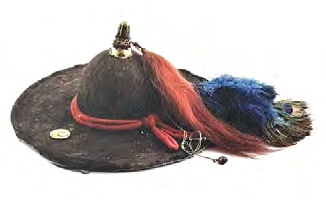


쿼리: 탕건
텍스트 검색 완료 (0.508초) - top 3

#1 | 페이지 98, 그림 3  탕건 조직 및 짜임새 A: 육안관찰, B: 현미경 관찰(x50). | 237x156 | 유사도: 0.5089
  컨텍스트: 그림 3  탕건 조직 및 짜임새 A: 육안관찰, B: 현미경 관찰(x50).
본 연구에서는 탕건이 말총으로 짠 뒤 먹을 도포한 공예품이라는 기록에 근거하여, 현대 말총과 상용 먹 (실크빌, KOR)을 구매하고 비교 분석을 진행하였다 (표 1). 현대 말총은 약품처리가 ...


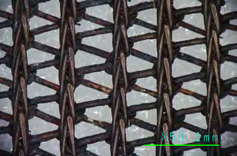


#2 | 페이지 97, 그림 1  각두 및 탕건 착용 사례 A: 차천로 초상(당진시 공립박물관 소장), | 284x332 | 유사도: 0.5082
  컨텍스트: 그림 1  각두 및 탕건 착용 사례 A: 차천로 초상(당진시 공립박물관 소장),
높으며 중간에 턱이 져서 탕건의 형태와 일치하지만, 사용된 재료가 비단으로 추정되는 반면 탕건은 말총 으로 제작되어 비교적 투명하게 묘사되어 있다(그림 1) (장경희 2000). 일부 문헌...


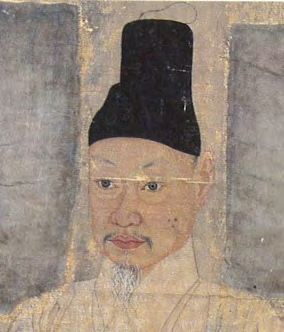


#3 | 페이지 98, 그림 2  탕건 세부 명칭(영천역사박물관 소장 탕건 사진 참고). | 270x216 | 유사도: 0.5080
  컨텍스트: 그림 2  탕건 세부 명칭(영천역사박물관 소장 탕건 사진 참고).
모정부는 가로 12.3 cm, 세로 7 cm를 이룬다(그림 2). 전세품으로서 오염 상태는 비교적 양호하나 장기간의 열화로 인해 재질이 약화되어 구조적으로는 불안정한 상태였다. 이를 위해 생물현미경(Ec...


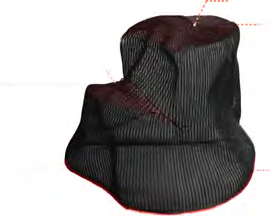


쿼리: 명 신종의 칙유에 기록된 관복 목록
텍스트 검색 완료 (0.471초) - top 3

#1 | 페이지 180, 그림 1  명 신종의 칙유에 기록된 관복 목록.36 | 1076x404 | 유사도: 0.5434
  컨텍스트: 그림 1  명 신종의 칙유에 기록된 관복 목록.36
1.  명 신종의 칙유(勅諭)에 기록된 상복(常服)과 피변복(皮弁服) 명 신종의 칙유는 1595년(萬曆 23) 정월 21일 작성 (舃) 1쌍【말(襪)을 갖춤】, 단반홍 평라에 금박을 입힌 겹 보 자기 4건, 저사 2필...


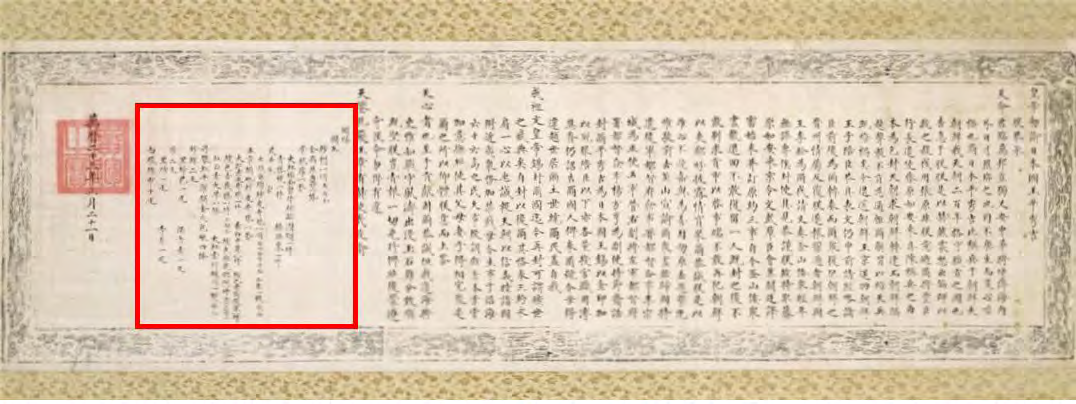


#2 | 페이지 183, 그림 3  1596년 우에스기 가게카츠(上杉景勝)에게 사여된 관복48 A: 사모 | 571x266 | 유사도: 0.5335
  컨텍스트: 그림 3  1596년 우에스기 가게카츠(上杉景勝)에게 사여된 관복48 A: 사모
및 묘법원 소장 복식 중 피변복 일습에 해당하는 것을 <그림 5>와 같이 정리하였다. 피변복의 상(裳)은 전상 (前裳)과 후상(後裳)이 서로 연결된 형태인데, 도설과 같은 조직의 원단으로 ...


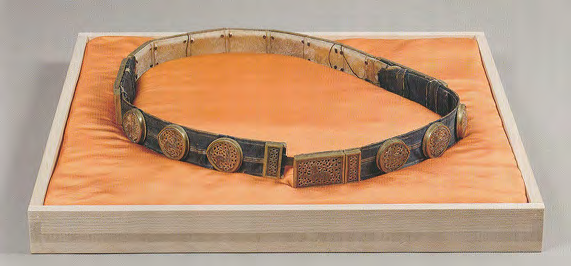


#3 | 페이지 183, 이미지 #7 | 116x177 | 유사도: 0.5279
  컨텍스트: 및 묘법원 소장 복식 중 피변복 일습에 해당하는 것을 <그림 5>와 같이 정리하였다. 피변복의 상(裳)은 전상 (前裳)과 후상(後裳)이 서로 연결된 형태인데, 도설과 치마와 운견·통수·스란 원령 『풍공유보도략』 도설 및 묘법원 소장 유품에는 칙 유에 기록된 상복과 피변...


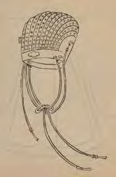

In [47]:
# 텍스트 → 이미지 검색
text_queries = [
    "두 자락치마",
    "찢어진 옷",
    "탕건",
    "명 신종의 칙유에 기록된 관복 목록",
]

for query in text_queries:
    print(f"\n{'='*60}")
    print(f"쿼리: {query}")
    print(f"{'='*60}")
    results = search_by_text(query, top_k=3)
    display_results(results)

## 테스트 2: 이미지로 유사 이미지 검색

추출된 이미지 중 하나를 쿼리로 사용하여 유사한 이미지를 검색합니다.

쿼리 이미지: 페이지 1, 이미지 #0 (152x312)


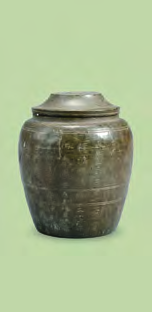


유사 이미지 검색 결과:
이미지 검색 완료 (0.825초) - top 6

#1 | 페이지 3, 이미지 #0 | 152x312 | 유사도: 0.7225
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


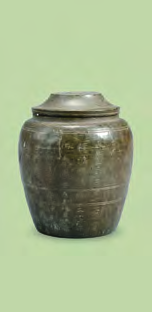


#2 | 페이지 1, 이미지 #0 | 152x312 | 유사도: 0.7225
  컨텍스트: KOREAN JOURNAL OF 
HERITAGE: HISTORY & SCIENCE
Vol. 58 No. 4 (Serial No. 110) 제58권·제4호
헤리티지
:역사와 과학


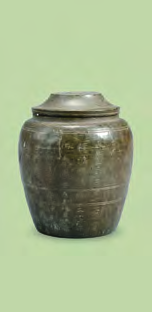


#3 | 페이지 110, 그림 1C). 항 | 571x608 | 유사도: 0.6791
  컨텍스트: 그림 1C). 항
108  KOREAN JOURNAL OF HERITAGE: HISTORY & SCIENCE Vol. 58 No. 4 A
B C D
E
F


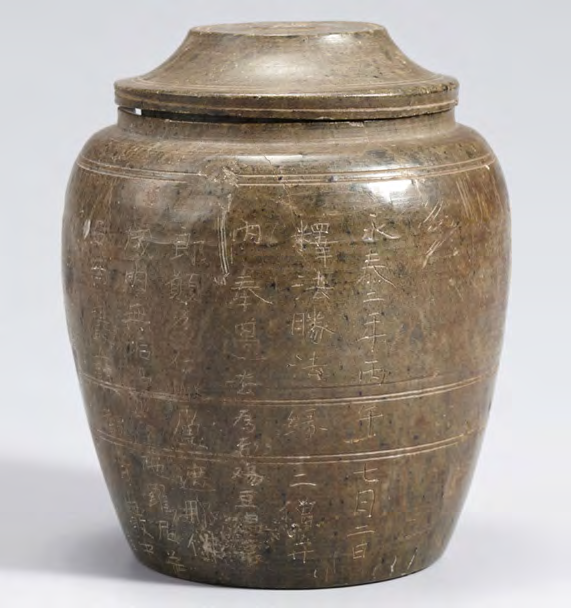


#4 | 페이지 184, 이미지 #3 | 220x249 | 유사도: 0.6555


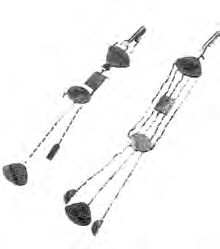


#5 | 페이지 110, 그림 1  산청 석남암사지 석조비로자나불좌상 납석사리호의 보존현황. A: 사리호의 전체모습, B: 항아리 내부 모습, C: 항아리 저부(바닥면), D: 개(뚜껑)의 | 322x241 | 유사도: 0.6522
  컨텍스트: 그림 1  산청 석남암사지 석조비로자나불좌상 납석사리호의 보존현황. A: 사리호의 전체모습, B: 항아리 내부 모습, C: 항아리 저부(바닥면), D: 개(뚜껑)의
밑 부분은 평편하고 넓어 안정감을 준다(그림 1C). 항 아리의 구연부 아랫부분과 몸체의 중간, 그리고 ...


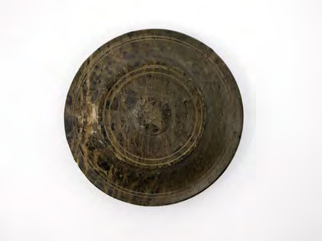

In [48]:
# 이미지 → 유사 이미지 검색 (첫 번째 이미지를 쿼리로 사용)
query_img = all_images[0]
label = query_img["caption"] if query_img["caption"] else f"이미지 #{query_img['img_idx']}"
print(f"쿼리 이미지: 페이지 {query_img['page']}, {label} ({query_img['width']}x{query_img['height']})")
display(IPImage(data=query_img["bytes"], width=300))

print("\n유사 이미지 검색 결과:")
# top_k=6으로 검색 (자기 자신 포함되므로 +1)
results = search_by_image(query_img["bytes"], mime_type=query_img["mime_type"], top_k=6)
# 자기 자신(유사도 ~1.0) 제외
results = [r for r in results if r["score"] < 0.99][:5]
display_results(results)